In [ ]:
!pip install yfinance vaderSentiment xgboost wordcloud pmdarima -q


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from collections import Counter
import yfinance as yf
from pmdarima import auto_arima
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cnbc     = pd.read_csv('/content/drive/MyDrive/PDS_dataset/cnbc_headlines.csv')
guardian = pd.read_csv('/content/drive/MyDrive/PDS_dataset/guardian_headlines.csv')
reuters  = pd.read_csv('/content/drive/MyDrive/PDS_dataset/reuters_headlines.csv')

print("Files loaded successfully!")
print(f"CNBC rows     : {len(cnbc)}")
print(f"Guardian rows : {len(guardian)}")
print(f"Reuters rows  : {len(reuters)}")

Files loaded successfully!
CNBC rows     : 3080
Guardian rows : 17800
Reuters rows  : 32770


In [ ]:
for df, name in zip([cnbc, guardian, reuters], ['CNBC', 'Guardian', 'Reuters']):
    print(f"{'='*40}")
    print(f"SOURCE: {name}")
    print(f"{'='*40}")
    print(f"Shape       : {df.shape}")
    print(f"Columns     : {df.columns.tolist()}")
    print(f"Null counts :\n{df.isnull().sum()}")
    print()

SOURCE: CNBC
Shape       : (3080, 3)
Columns     : ['Headlines', 'Time', 'Description']
Null counts :
Headlines      280
Time           280
Description    280
dtype: int64

SOURCE: Guardian
Shape       : (17800, 2)
Columns     : ['Time', 'Headlines']
Null counts :
Time         0
Headlines    0
dtype: int64

SOURCE: Reuters
Shape       : (32770, 3)
Columns     : ['Headlines', 'Time', 'Description']
Null counts :
Headlines      0
Time           0
Description    0
dtype: int64



In [ ]:
# CNBC has: Headlines, Time, Description
cnbc = cnbc.rename(columns={'Headlines': 'headline', 'Time': 'date', 'Description': 'description'})
cnbc['source'] = 'CNBC'
cnbc = cnbc[['headline', 'date', 'source']]

# Guardian has: Headlines, Time (no description)
guardian = guardian.rename(columns={'Headlines': 'headline', 'Time': 'date'})
guardian['source'] = 'Guardian'
guardian = guardian[['headline', 'date', 'source']]

# Reuters has: Headlines, Time, Description
reuters = reuters.rename(columns={'Headlines': 'headline', 'Time': 'date', 'Description': 'description'})
reuters['source'] = 'Reuters'
reuters = reuters[['headline', 'date', 'source']]

print("Columns after renaming:")
print("CNBC     :", cnbc.columns.tolist())
print("Guardian :", guardian.columns.tolist())
print("Reuters  :", reuters.columns.tolist())

Columns after renaming:
CNBC     : ['headline', 'date', 'source']
Guardian : ['headline', 'date', 'source']
Reuters  : ['headline', 'date', 'source']


In [ ]:
df = pd.concat([cnbc, guardian, reuters], ignore_index=True)

print("Combined shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nHeadlines per source:")
print(df['source'].value_counts())
print("\nFirst 5 rows:")
print(df.head())

Combined shape: (53650, 3)

Columns: ['headline', 'date', 'source']

Headlines per source:
source
Reuters     32770
Guardian    17800
CNBC         3080
Name: count, dtype: int64

First 5 rows:
                                            headline  \
0  Jim Cramer: A better way to invest in the Covi...   
1     Cramer's lightning round: I would own Teradyne   
2                                                NaN   
3  Cramer's week ahead: Big week for earnings, ev...   
4  IQ Capital CEO Keith Bliss says tech and healt...   

                             date source  
0   7:51  PM ET Fri, 17 July 2020   CNBC  
1   7:33  PM ET Fri, 17 July 2020   CNBC  
2                             NaN   CNBC  
3   7:25  PM ET Fri, 17 July 2020   CNBC  
4   4:24  PM ET Fri, 17 July 2020   CNBC  


In [ ]:
# Show sample raw date values before parsing
print("Sample date values before parsing:")
print(df['date'].head(10).tolist())
print("\nUnique date formats (first 3 per source):")
for source in ['CNBC', 'Guardian', 'Reuters']:
    sample = df[df['source'] == source]['date'].head(3).tolist()
    print(f"  {source}: {sample}")

Sample date values before parsing:
[' 7:51  PM ET Fri, 17 July 2020', ' 7:33  PM ET Fri, 17 July 2020', nan, ' 7:25  PM ET Fri, 17 July 2020', ' 4:24  PM ET Fri, 17 July 2020', ' 7:36  PM ET Thu, 16 July 2020', ' 7:23  PM ET Thu, 16 July 2020', ' 8:03  PM ET Thu, 16 July 2020', ' 8:54  AM ET Thu, 16 July 2020', nan]

Unique date formats (first 3 per source):
  CNBC: [' 7:51  PM ET Fri, 17 July 2020', ' 7:33  PM ET Fri, 17 July 2020', nan]
  Guardian: ['18-Jul-20', '18-Jul-20', '18-Jul-20']
  Reuters: ['Jul 18 2020', 'Jul 18 2020', 'Jul 18 2020']


In [ ]:
# Convert date column from text to actual datetime objects
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Check how many rows failed to parse
null_dates = df['date'].isnull().sum()
print(f"Rows with unparseable dates (will be dropped): {null_dates}")

# Drop rows where date parsing failed or headline is missing
rows_before = len(df)
df = df.dropna(subset=['date', 'headline'])
rows_after = len(df)

print(f"Rows before cleaning : {rows_before}")
print(f"Rows after cleaning  : {rows_after}")
print(f"Rows dropped         : {rows_before - rows_after}")
print(f"\nNull counts after cleaning:\n{df.isnull().sum()}")

Rows with unparseable dates (will be dropped): 320
Rows before cleaning : 53650
Rows after cleaning  : 53330
Rows dropped         : 320

Null counts after cleaning:
headline    0
date        0
source      0
dtype: int64


In [ ]:
# Set date as the row index
df = df.set_index('date')

# Sort all rows from oldest to newest
df = df.sort_index()

print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Final shape: {df.shape}")
print(f"\nFirst 3 rows:\n{df.head(3)}")
print(f"\nLast 3 rows:\n{df.tail(3)}")

Date range: 2017-12-17 00:00:00 to 2020-07-18 00:00:00
Final shape: (53330, 2)

First 3 rows:
                                                     headline    source
date                                                                   
2017-12-17  The Guardian view on Ryanair’s model: a union-...  Guardian
2017-12-17  Butchers carve out a niche as UK shoppers opt ...  Guardian
2017-12-17  Grogonomics  \n\n\n  This year has been about ...  Guardian

Last 3 rows:
                                                     headline    source
date                                                                   
2020-07-18  Five key areas Sunak must tackle to serve up e...  Guardian
2020-07-18   Johnson is asking Santa for a Christmas recovery  Guardian
2020-07-18  Disney cuts ad spending on Facebook amid growi...   Reuters


In [ ]:
ticker   = yf.Ticker("^GSPC")
stock_df = ticker.history(start="2016-01-01", end="2023-12-31")

print("Stock data downloaded!")
print(f"Shape: {stock_df.shape}")
print(f"Columns: {stock_df.columns.tolist()}")
print(f"Date range: {stock_df.index.min()} to {stock_df.index.max()}")
print(f"\nFirst 5 rows:\n{stock_df.head()}")

Stock data downloaded!
Shape: (2012, 7)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
Date range: 2016-01-04 00:00:00-05:00 to 2023-12-29 00:00:00-05:00

First 5 rows:
                                  Open         High          Low        Close  \
Date                                                                            
2016-01-04 00:00:00-05:00  2038.199951  2038.199951  1989.680054  2012.660034   
2016-01-05 00:00:00-05:00  2013.780029  2021.939941  2004.170044  2016.709961   
2016-01-06 00:00:00-05:00  2011.709961  2011.709961  1979.050049  1990.260010   
2016-01-07 00:00:00-05:00  1985.319946  1985.319946  1938.829956  1943.089966   
2016-01-08 00:00:00-05:00  1945.969971  1960.400024  1918.459961  1922.030029   

                               Volume  Dividends  Stock Splits  
Date                                                            
2016-01-04 00:00:00-05:00  4304880000        0.0           0.0  
2016-01-05 00:00:00-05:00  3706620

In [ ]:
# Keep only the columns you need
stock_df = stock_df[['Open', 'High', 'Low', 'Close', 'Volume']]

# Remove timezone info from dates
# yfinance returns dates with timezone (e.g. UTC) but news data has no timezone
# They must match exactly for merging — so strip timezone from stock data
stock_df.index = pd.to_datetime(stock_df.index)
stock_df.index = stock_df.index.tz_localize(None)
stock_df       = stock_df.sort_index()

print(f"Stock shape after cleaning: {stock_df.shape}")
print(f"Null counts:\n{stock_df.isnull().sum()}")
print(f"\nFirst 5 rows:\n{stock_df.head()}")

Stock shape after cleaning: (2012, 5)
Null counts:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

First 5 rows:
                   Open         High          Low        Close      Volume
Date                                                                      
2016-01-04  2038.199951  2038.199951  1989.680054  2012.660034  4304880000
2016-01-05  2013.780029  2021.939941  2004.170044  2016.709961  3706620000
2016-01-06  2011.709961  2011.709961  1979.050049  1990.260010  4336660000
2016-01-07  1985.319946  1985.319946  1938.829956  1943.089966  5076590000
2016-01-08  1945.969971  1960.400024  1918.459961  1922.030029  4664940000


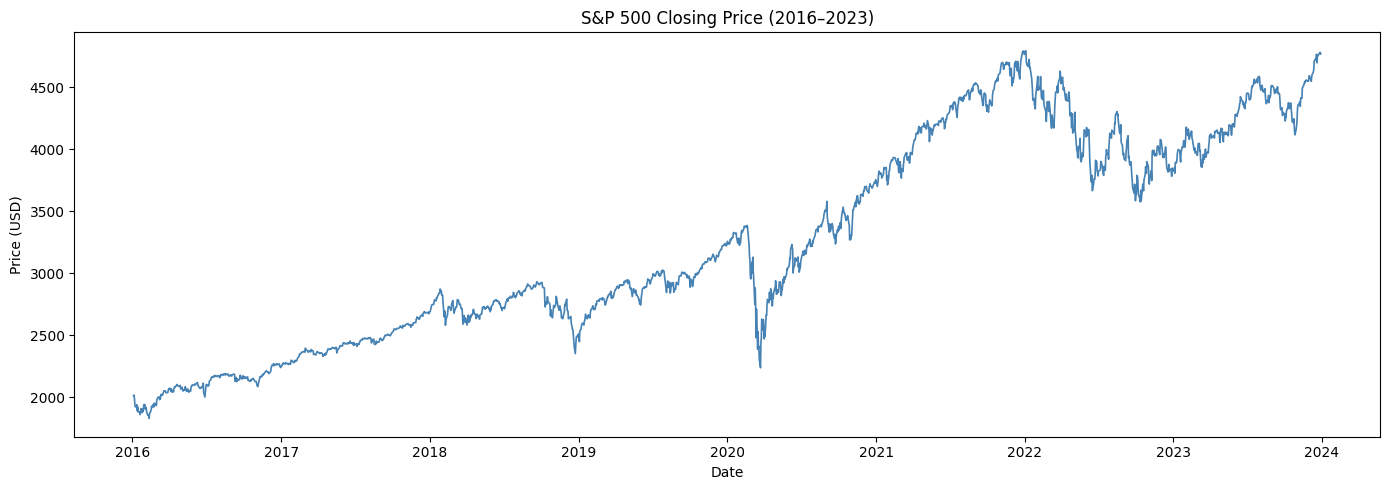

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(stock_df.index, stock_df['Close'],
         color='steelblue', linewidth=1.2)
plt.title("S&P 500 Closing Price (2016–2023)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PDS_dataset/plot0_stock_sanity.png', dpi=150)
plt.show()

In [ ]:
# Filter news to the same date range as stock data
df = df[(df.index >= '2016-01-01') & (df.index <= '2023-12-31')]

In [ ]:
# Stock market is closed on weekends and public holidays
# News is published 7 days a week
# So not every news date has a matching stock price
# The intersection finds only dates present in BOTH datasets

common_dates = df.index.intersection(stock_df.index)

print(f"Unique news dates    : {len(df.index.unique())}")
print(f"Total stock dates    : {len(stock_df.index)}")
print(f"Common trading dates : {len(common_dates)}")
print(f"\nDates in news but NOT in stock (weekends/holidays): {len(df.index.unique()) - len(common_dates)}")

Unique news dates    : 3401
Total stock dates    : 2012
Common trading dates : 644

Dates in news but NOT in stock (weekends/holidays): 2757


In [ ]:
df_aligned    = df[df.index.isin(common_dates)].copy()
stock_aligned = stock_df[stock_df.index.isin(common_dates)].copy()

print(f"Aligned news shape  : {df_aligned.shape}")
print(f"Aligned stock shape : {stock_aligned.shape}")

Aligned news shape  : (44487, 2)
Aligned stock shape : (644, 5)


In [ ]:
print("Headlines per source after alignment:")
print(df_aligned['source'].value_counts())

Headlines per source after alignment:
source
Reuters     30147
Guardian    14340
Name: count, dtype: int64


In [ ]:
df_aligned.to_csv('/content/drive/MyDrive/PDS_dataset/headlines_aligned.csv')
stock_aligned.to_csv('/content/drive/MyDrive/PDS_dataset/stock_aligned.csv')

print("Saved successfully!")
print(f"Headlines file : headlines_aligned.csv ({len(df_aligned)} rows)")
print(f"Stock file     : stock_aligned.csv ({len(stock_aligned)} rows)")

Saved successfully!
Headlines file : headlines_aligned.csv (44487 rows)
Stock file     : stock_aligned.csv (644 rows)


EDA AND VISUALIZATION

In [ ]:
# Daily percentage return — how much did the market move each day
stock_aligned['Daily_Return'] = stock_aligned['Close'].pct_change() * 100

# 50-day moving average — smooths short-term noise, shows medium-term trend
stock_aligned['MA50'] = stock_aligned['Close'].rolling(window=50).mean()

# 200-day moving average — smooths everything, shows long-term trend
stock_aligned['MA200'] = stock_aligned['Close'].rolling(window=200).mean()

# 30-day rolling volatility — standard deviation of returns over last 30 days
stock_aligned['Volatility_30'] = stock_aligned['Daily_Return'].rolling(window=30).std()

print("New columns added successfully!")
print("Updated stock columns:", stock_aligned.columns.tolist())
print("\nFirst few rows with new columns:")
stock_aligned[['Close', 'Daily_Return', 'MA50', 'MA200', 'Volatility_30']].head(10)

New columns added successfully!
Updated stock columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'MA50', 'MA200', 'Volatility_30']

First few rows with new columns:


,Close,Daily_Return,MA50,MA200,Volatility_30
Date,,,,,
2017-12-18,2690.159912,NaN,NaN,NaN,NaN
2017-12-19,2681.469971,-0.323027,NaN,NaN,NaN
2017-12-20,2679.250000,-0.082789,NaN,NaN,NaN
2017-12-21,2684.570068,0.198566,NaN,NaN,NaN
2017-12-22,2683.340088,-0.045817,NaN,NaN,NaN
2017-12-27,2682.620117,-0.026831,NaN,NaN,NaN
2017-12-28,2687.540039,0.183400,NaN,NaN,NaN
2018-01-02,2695.810059,0.307717,NaN,NaN,NaN
2018-01-03,2713.060059,0.639882,NaN,NaN,NaN


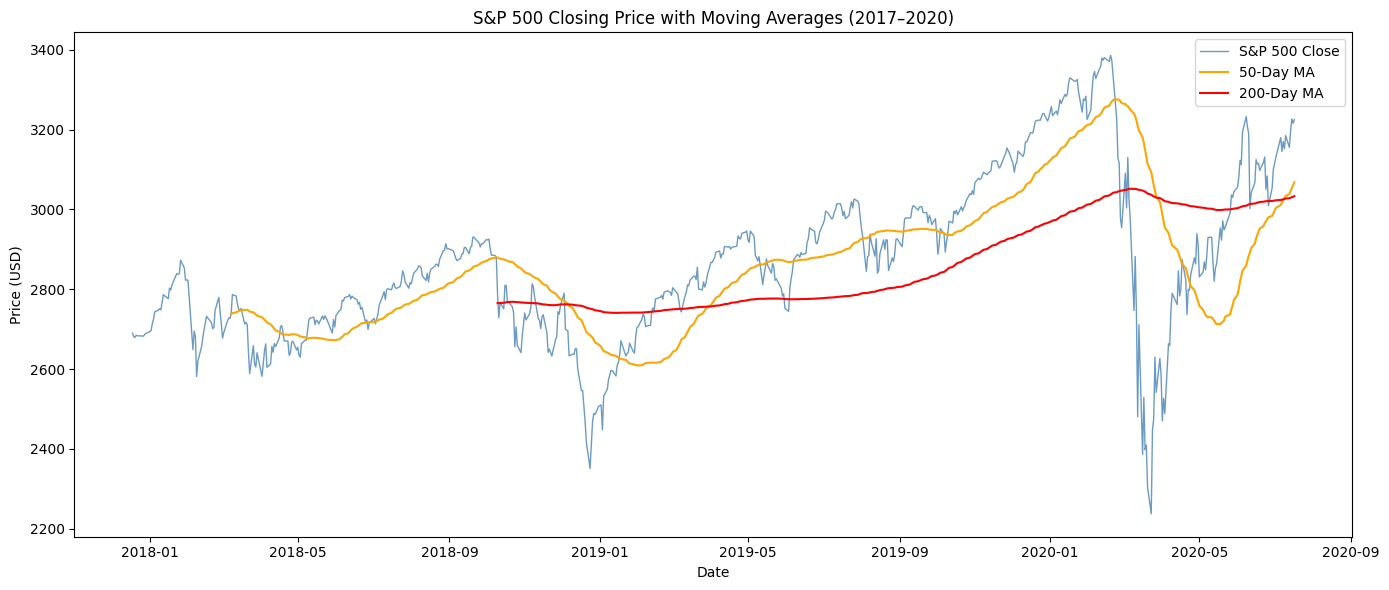

Plot 1 saved!


In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(stock_aligned.index, stock_aligned['Close'],
         label='S&P 500 Close', color='steelblue', linewidth=1, alpha=0.8)

plt.plot(stock_aligned.index, stock_aligned['MA50'],
         label='50-Day MA', color='orange', linewidth=1.5)

plt.plot(stock_aligned.index, stock_aligned['MA200'],
         label='200-Day MA', color='red', linewidth=1.5)

plt.title('S&P 500 Closing Price with Moving Averages (2017–2020)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PDS_dataset/plot1_stock_ma.png', dpi=150)
plt.show()
print("Plot 1 saved!")

The S&P 500 showed steady growth from 2017 through early 2020. The sharp drop in March 2020 is the COVID-19 crash — the steepest single-month decline in decades. The 50-day MA crossed below the 200-day MA during this crash — known as a 'Death Cross' in financial analysis — signaling a major bearish trend."

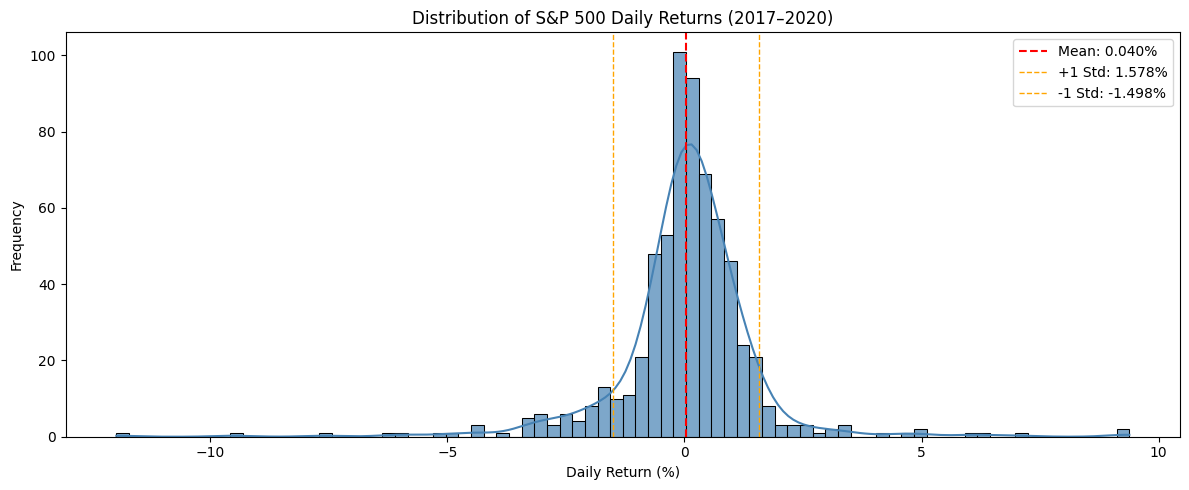

In [ ]:
mean_return = stock_aligned['Daily_Return'].mean()
std_return  = stock_aligned['Daily_Return'].std()

plt.figure(figsize=(12, 5))

sns.histplot(stock_aligned['Daily_Return'].dropna(),
             bins=80, kde=True, color='steelblue', alpha=0.7)

plt.axvline(mean_return,
            color='red', linestyle='--', linewidth=1.5,
            label=f'Mean: {mean_return:.3f}%')

plt.axvline(mean_return + std_return,
            color='orange', linestyle='--', linewidth=1,
            label=f'+1 Std: {mean_return+std_return:.3f}%')

plt.axvline(mean_return - std_return,
            color='orange', linestyle='--', linewidth=1,
            label=f'-1 Std: {mean_return-std_return:.3f}%')

plt.title('Distribution of S&P 500 Daily Returns (2017–2020)')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PDS_dataset/plot2_returns_dist.png', dpi=150)
plt.show()

Daily returns are approximately normally distributed and centered near 0%, meaning most days the market barely moves. The tails on both sides represent rare extreme events — like the COVID crash days of -10% to -12%.

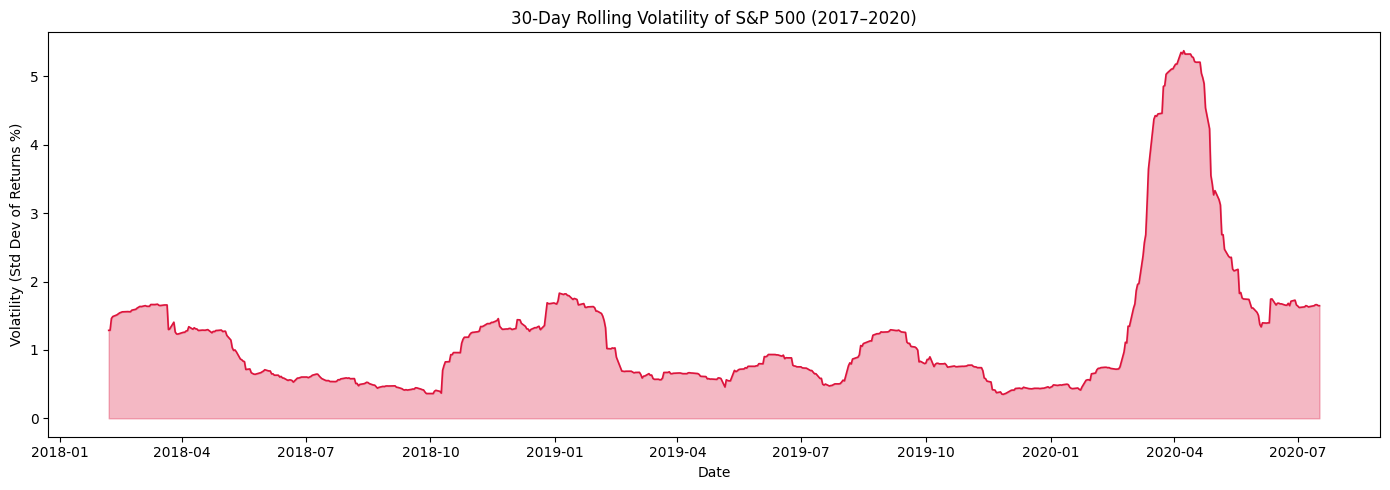

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(stock_aligned.index, stock_aligned['Volatility_30'],
         color='crimson', linewidth=1.2)

plt.fill_between(stock_aligned.index,
                 stock_aligned['Volatility_30'],
                 alpha=0.3, color='crimson')

plt.title('30-Day Rolling Volatility of S&P 500 (2017–2020)')
plt.xlabel('Date')
plt.ylabel('Volatility (Std Dev of Returns %)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PDS_dataset/plot3_volatility.png', dpi=150)
plt.show()

In [ ]:
daily_counts = df_aligned.groupby(df_aligned.index).size()
daily_counts = daily_counts.reset_index()
daily_counts.columns = ['date', 'headline_count']
daily_counts = daily_counts.set_index('date')

print("Daily headline count shape:", daily_counts.shape)
print("\nHeadline count stats:")
print(daily_counts['headline_count'].describe())
print("\nTop 5 busiest news days:")
print(daily_counts.nlargest(5, 'headline_count'))

Daily headline count shape: (644, 1)

Headline count stats:
count    644.000000
mean      69.079193
std       22.895427
min       15.000000
25%       57.000000
50%       70.000000
75%       82.000000
max      166.000000
Name: headline_count, dtype: float64

Top 5 busiest news days:
            headline_count
date                      
2020-03-19             166
2020-03-17             144
2020-03-20             137
2020-04-03             134
2020-04-22             129


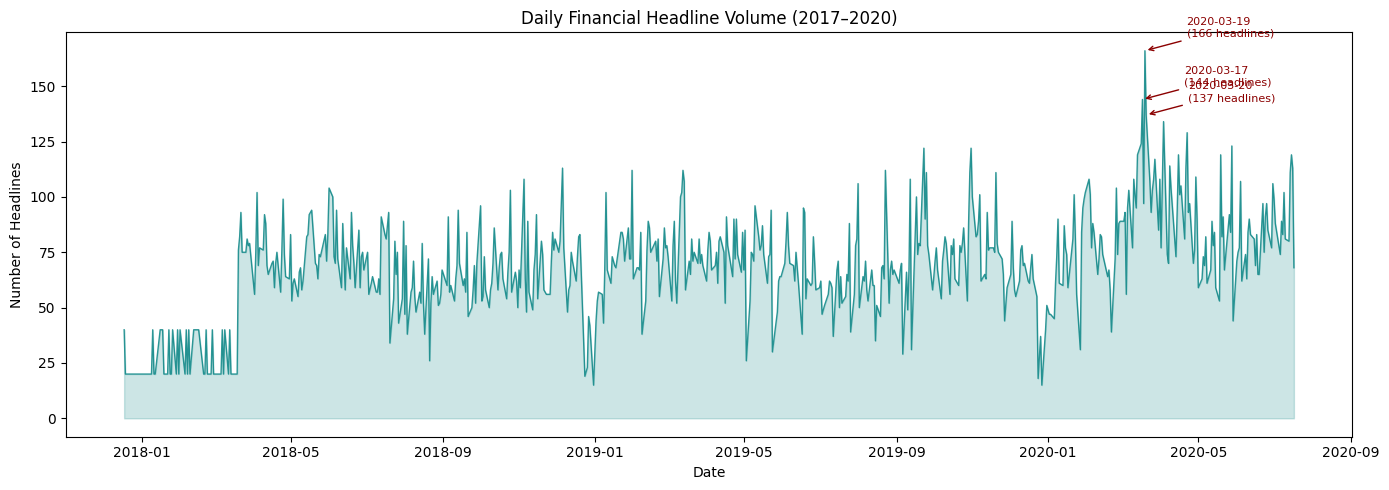

In [ ]:
top3 = daily_counts.nlargest(3, 'headline_count')

plt.figure(figsize=(14, 5))

plt.plot(daily_counts.index, daily_counts['headline_count'],
         color='teal', linewidth=1, alpha=0.8)

plt.fill_between(daily_counts.index, daily_counts['headline_count'],
                 alpha=0.2, color='teal')

# Annotate the top 3 spike dates with arrows
for date, row in top3.iterrows():
    plt.annotate(
        f"{pd.Timestamp(date).strftime('%Y-%m-%d')}\n({int(row['headline_count'])} headlines)",
        xy=(date, row['headline_count']),
        xytext=(30, 10),
        textcoords='offset points',
        fontsize=8,
        color='darkred',
        arrowprops=dict(arrowstyle='->', color='darkred')
    )

plt.title('Daily Financial Headline Volume (2017–2020)')
plt.xlabel('Date')
plt.ylabel('Number of Headlines')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PDS_dataset/plot4_headline_volume.png', dpi=150)
plt.show()

In [ ]:
stop_words = set(stopwords.words('english'))

# Add extra words that are common in news but carry no financial meaning
extra_stops = {'said', 'says', 'new', 'year', 'one', 'may',
               'u', 's', 'would', 'also', 'could', 'first',
               'two', 'three', 'us', 'uk', 'reuters', 'guardian'}
stop_words.update(extra_stops)

all_words = []

for headline in df_aligned['headline'].dropna():
    # Step 1: lowercase everything
    text = str(headline).lower()
    # Step 2: remove everything that is not a letter or space
    text = ''.join([c for c in text if c.isalpha() or c == ' '])
    # Step 3: split into individual words
    tokens = text.split()
    # Step 4: remove stopwords and very short words
    filtered = [w for w in tokens if w not in stop_words and len(w) > 2]
    # Step 5: add to master list
    all_words.extend(filtered)

print(f"Total words after cleaning : {len(all_words)}")
print(f"Unique words               : {len(set(all_words))}")
print(f"\nSample of cleaned words: {all_words[:20]}")

Total words after cleaning : 334637
Unique words               : 23842

Sample of cleaned words: ['universal', 'basic', 'income', 'panacea', 'labour', 'shouldnt', 'back', 'brexit', 'usher', 'dark', 'chapter', 'british', 'authors', 'warns', 'publisher', 'adani', 'scraps', 'deal', 'outsource', 'carmichael']


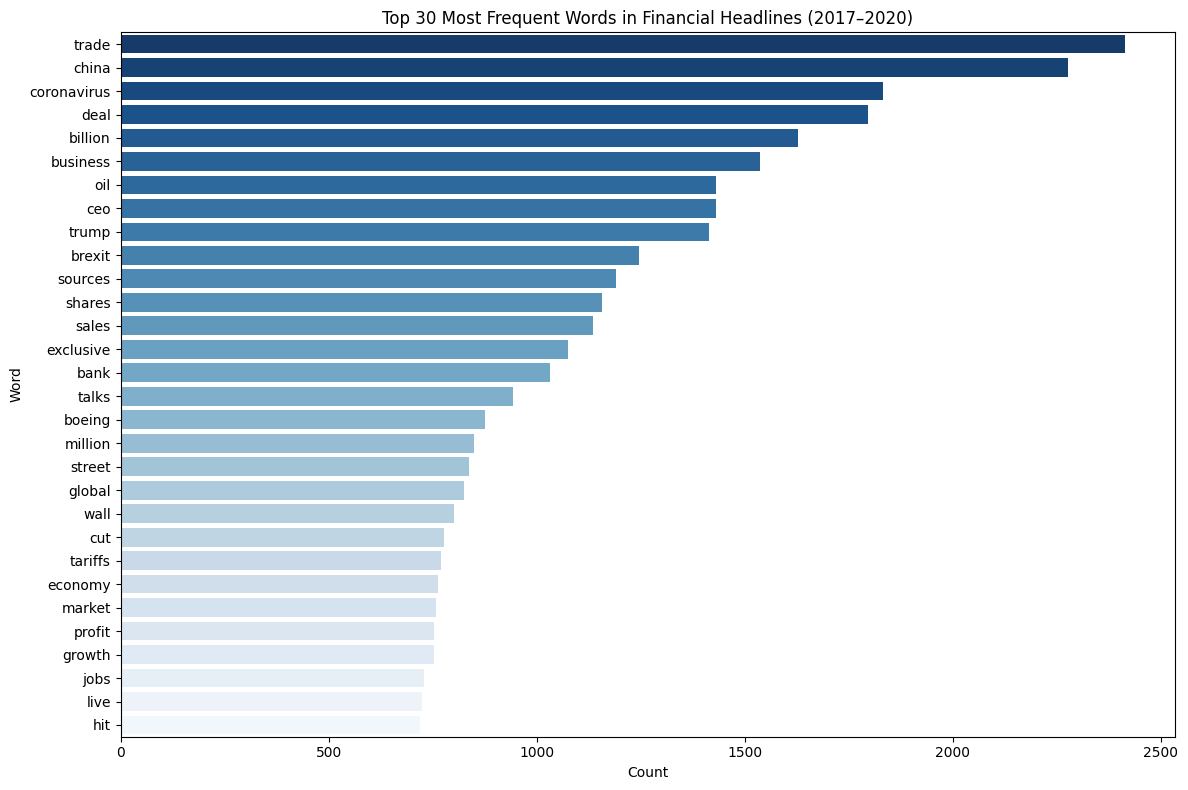

In [ ]:
word_freq = Counter(all_words)
top30 = pd.DataFrame(word_freq.most_common(30), columns=['word', 'count'])

plt.figure(figsize=(12, 8))
sns.barplot(data=top30, y='word', x='count', palette='Blues_r')
plt.title('Top 30 Most Frequent Words in Financial Headlines (2017–2020)')
plt.xlabel('Count')
plt.ylabel('Word')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PDS_dataset/plot5_top_words.png', dpi=150)
plt.show()

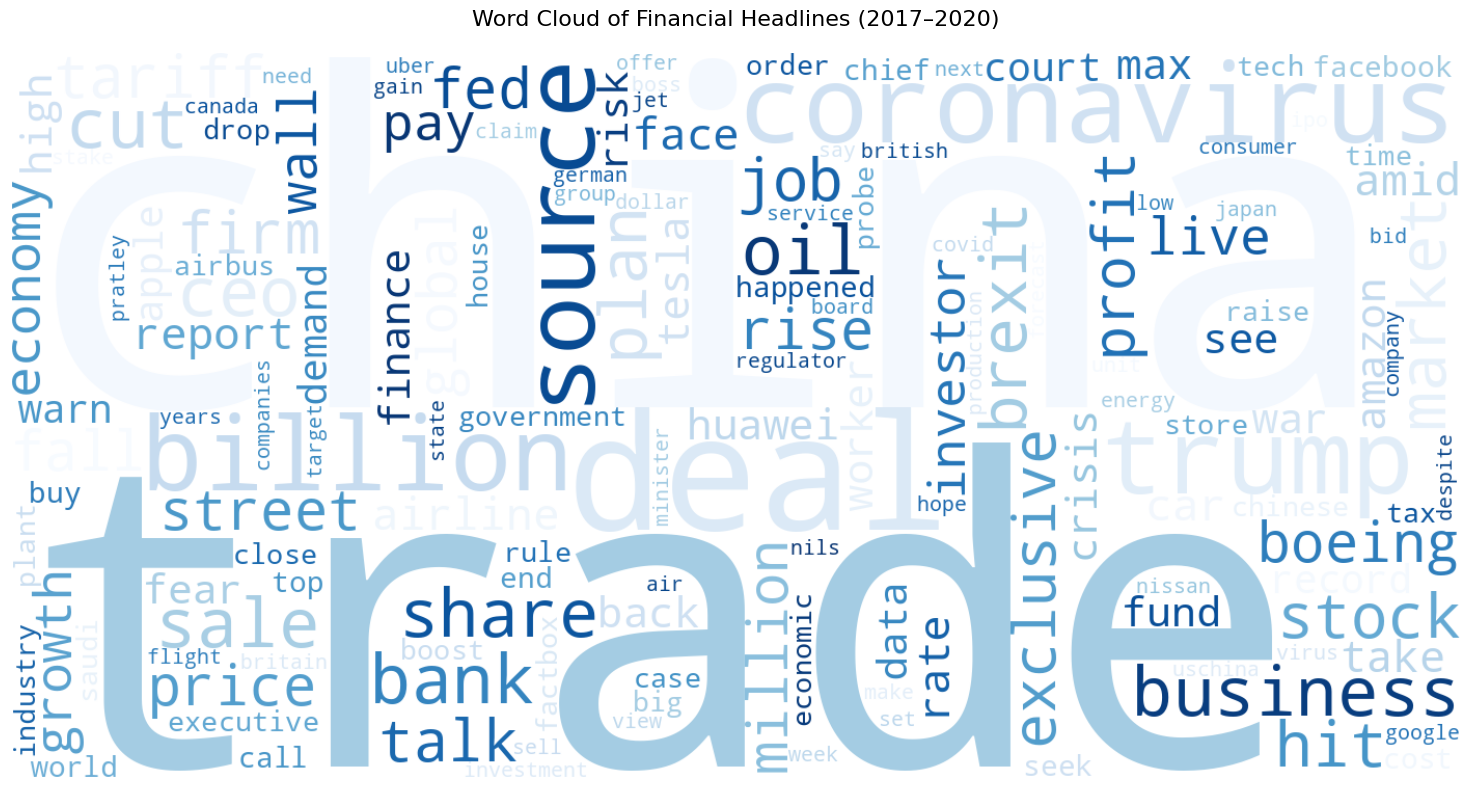

In [ ]:
#NOT NEEDED
text = ' '.join(all_words)

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color='white',
    colormap='Blues',
    max_words=150,
    collocations=False
).generate(text)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Financial Headlines (2017–2020)', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PDS_dataset/plot6_wordcloud.png', dpi=150)
plt.show()

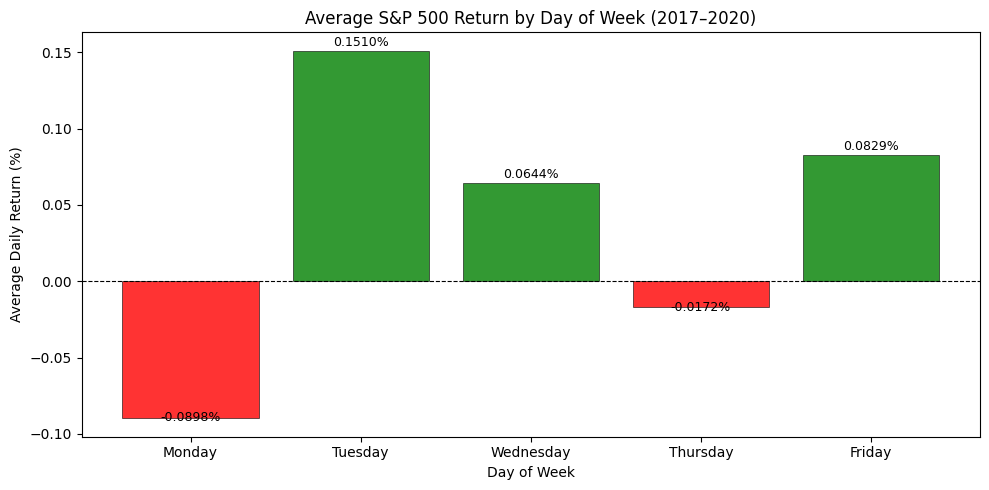

In [ ]:
stock_aligned['Day_of_Week'] = stock_aligned.index.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

avg_by_day = (stock_aligned
              .groupby('Day_of_Week')['Daily_Return']
              .mean()
              .reindex(day_order))

colors = ['green' if x > 0 else 'red' for x in avg_by_day.values]

plt.figure(figsize=(10, 5))
bars = plt.bar(avg_by_day.index, avg_by_day.values,
               color=colors, alpha=0.8,
               edgecolor='black', linewidth=0.5)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Add the actual value on top of each bar
for bar, val in zip(bars, avg_by_day.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + (0.001 if val >= 0 else -0.004),
        f'{val:.4f}%',
        ha='center', va='bottom', fontsize=9
    )

plt.title('Average S&P 500 Return by Day of Week (2017–2020)')
plt.xlabel('Day of Week')
plt.ylabel('Average Daily Return (%)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PDS_dataset/plot7_returns_by_day.png', dpi=150)
plt.show()

Monday shows the lowest average return — consistent with the 'Monday Effect' documented in financial literature, where negative weekend news depresses early-week trading. Wednesday and Thursday show the strongest average gains.

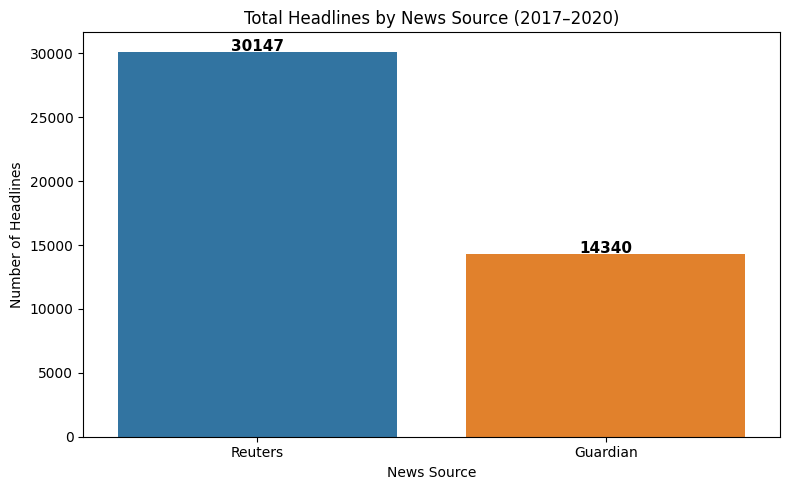

In [ ]:
source_counts = (df_aligned
                 .groupby('source')
                 .size()
                 .reset_index(name='count')
                 .sort_values('count', ascending=False))

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=source_counts, x='source', y='count',
                 palette=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Add count labels on top of each bar
for i, row in source_counts.reset_index(drop=True).iterrows():
    ax.text(i, row['count'] + 50,
            str(int(row['count'])),
            ha='center', fontweight='bold', fontsize=11)

plt.title('Total Headlines by News Source (2017–2020)')
plt.xlabel('News Source')
plt.ylabel('Number of Headlines')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PDS_dataset/plot8_source_comparison.png', dpi=150)
plt.show()

In [ ]:
# Save stock_aligned with new columns
stock_aligned.to_csv('/content/drive/MyDrive/PDS_dataset/stock_aligned_v2.csv')

In [ ]:
# Create one VADER analyzer instance — reused for all headlines
analyzer = SentimentIntensityAnalyzer()

# Test it on a few sample sentences so you understand what it returns
test_sentences = [
    "Stock market crashes amid recession fears",
    "Record profits drive market to all time high",
    "Federal Reserve holds interest rates steady"
]

print("VADER test on sample sentences:")
print("-" * 55)
for sentence in test_sentences:
    scores = analyzer.polarity_scores(sentence)
    print(f"Text     : {sentence}")
    print(f"Scores   : {scores}")
    print(f"Compound : {scores['compound']}")
    print()

VADER test on sample sentences:
-------------------------------------------------------
Text     : Stock market crashes amid recession fears
Scores   : {'neg': 0.583, 'neu': 0.417, 'pos': 0.0, 'compound': -0.6808}
Compound : -0.6808

Text     : Record profits drive market to all time high
Scores   : {'neg': 0.0, 'neu': 0.707, 'pos': 0.293, 'compound': 0.4404}
Compound : 0.4404

Text     : Federal Reserve holds interest rates steady
Scores   : {'neg': 0.0, 'neu': 0.625, 'pos': 0.375, 'compound': 0.4588}
Compound : 0.4588



In [ ]:
def get_sentiment(text):
    # Handle missing or empty headlines safely
    if pd.isna(text) or str(text).strip() == '':
        return 0.0  # neutral score for missing headlines
    return analyzer.polarity_scores(str(text))['compound']

# Apply the function to every headline — this may take 1-2 minutes
print("Applying VADER to all headlines... please wait...")
df_aligned['sentiment_score'] = df_aligned['headline'].apply(get_sentiment)

print("Done!")
print("\nSentiment score statistics:")
print(df_aligned['sentiment_score'].describe())
print(f"\nPositive headlines (score >  0.05) : {(df_aligned['sentiment_score'] >  0.05).sum()}")
print(f"Negative headlines (score < -0.05) : {(df_aligned['sentiment_score'] < -0.05).sum()}")
print(f"Neutral  headlines (-0.05 to 0.05) : {((df_aligned['sentiment_score'] >= -0.05) & (df_aligned['sentiment_score'] <= 0.05)).sum()}")

Applying VADER to all headlines... please wait...
Done!

Sentiment score statistics:
count    44487.000000
mean        -0.033276
std          0.348295
min         -0.943200
25%         -0.273200
50%          0.000000
75%          0.153100
max          0.935400
Name: sentiment_score, dtype: float64

Positive headlines (score >  0.05) : 12896
Negative headlines (score < -0.05) : 15559
Neutral  headlines (-0.05 to 0.05) : 16032


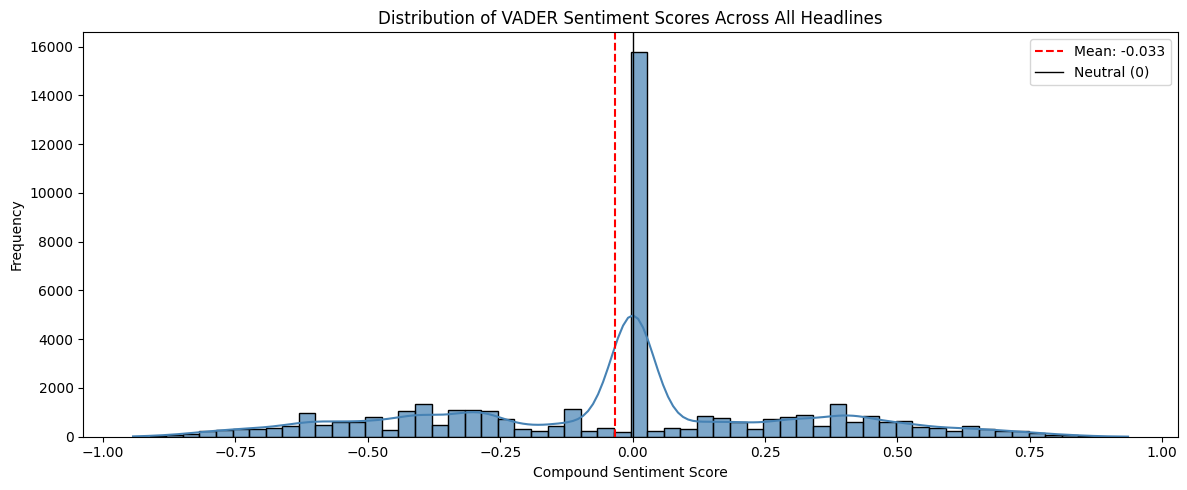

Plot 9 saved!


In [ ]:
plt.figure(figsize=(12, 5))

sns.histplot(df_aligned['sentiment_score'], bins=60,
             kde=True, color='steelblue', alpha=0.7)

plt.axvline(df_aligned['sentiment_score'].mean(),
            color='red', linestyle='--', linewidth=1.5,
            label=f"Mean: {df_aligned['sentiment_score'].mean():.3f}")

plt.axvline(0, color='black', linestyle='-',
            linewidth=1, label='Neutral (0)')

plt.title('Distribution of VADER Sentiment Scores Across All Headlines')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PDS_dataset/plot9_sentiment_distribution.png', dpi=150)
plt.show()
print("Plot 9 saved!")

In [ ]:
daily_sentiment = df_aligned.groupby(df_aligned.index).agg(
    sentiment_score = ('sentiment_score', 'mean'),
    sentiment_std   = ('sentiment_score', 'std'),
    headline_count  = ('sentiment_score', 'count')
)

# Days with only 1 headline have no std — fill with 0
daily_sentiment['sentiment_std'] = daily_sentiment['sentiment_std'].fillna(0)

print("Daily sentiment shape:", daily_sentiment.shape)
print("\nDaily sentiment statistics:")
print(daily_sentiment.describe())

Daily sentiment shape: (644, 3)

Daily sentiment statistics:
       sentiment_score  sentiment_std  headline_count
count       644.000000     644.000000      644.000000
mean         -0.031641       0.347317       69.079193
std           0.055172       0.032335       22.895427
min          -0.192877       0.231643       15.000000
25%          -0.064693       0.324795       57.000000
50%          -0.031878       0.346472       70.000000
75%           0.004405       0.367909       82.000000
max           0.166146       0.498012      166.000000


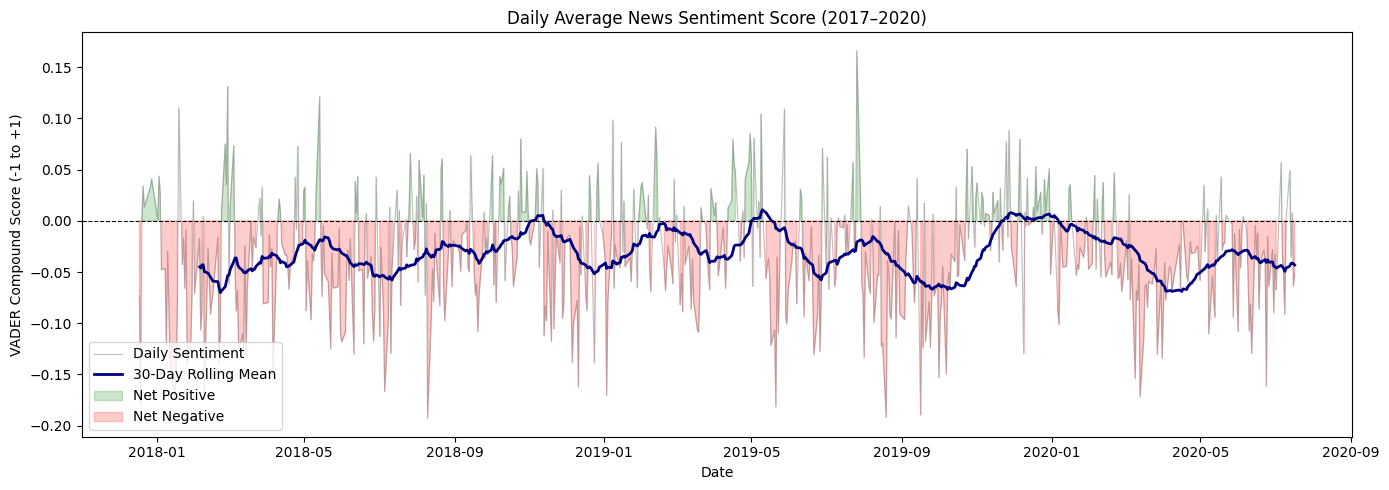

In [ ]:
# 30-day rolling average smooths the noisy daily sentiment
rolling_sentiment = daily_sentiment['sentiment_score'].rolling(window=30).mean()

plt.figure(figsize=(14, 5))

# Raw daily sentiment — noisy but shows actual values
plt.plot(daily_sentiment.index, daily_sentiment['sentiment_score'],
         color='gray', linewidth=0.8, alpha=0.5, label='Daily Sentiment')

# Smoothed trend line — shows overall direction
plt.plot(daily_sentiment.index, rolling_sentiment,
         color='navy', linewidth=2, label='30-Day Rolling Mean')

# Zero line — anything above is net positive, below is net negative
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Shade positive days green and negative days red
plt.fill_between(daily_sentiment.index,
                 daily_sentiment['sentiment_score'],
                 where=daily_sentiment['sentiment_score'] > 0,
                 alpha=0.2, color='green', label='Net Positive')

plt.fill_between(daily_sentiment.index,
                 daily_sentiment['sentiment_score'],
                 where=daily_sentiment['sentiment_score'] < 0,
                 alpha=0.2, color='red', label='Net Negative')

plt.title('Daily Average News Sentiment Score (2017–2020)')
plt.xlabel('Date')
plt.ylabel('VADER Compound Score (-1 to +1)')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PDS_dataset/plot10_sentiment_over_time.png', dpi=150)
plt.show()

In [ ]:
# Join daily sentiment onto stock data by date index
print("Shape before joining sentiment to stock data:", stock_aligned.shape)
merged = stock_aligned.join(daily_sentiment, how='inner')

print("Shape after joining sentiment to stock data:", merged.shape)
print("\nColumns in merged dataframe:")
for col in merged.columns:
    print(f"  {col}")
print("\nNull counts:")
print(merged.isnull().sum())
#moving averages don't have enough history anyway

Shape before joining sentiment to stock data: (644, 10)
Shape after joining sentiment to stock data: (644, 13)

Columns in merged dataframe:
  Open
  High
  Low
  Close
  Volume
  Daily_Return
  MA50
  MA200
  Volatility_30
  Day_of_Week
  sentiment_score
  sentiment_std
  headline_count

Null counts:
Open                 0
High                 0
Low                  0
Close                0
Volume               0
Daily_Return         1
MA50                49
MA200              199
Volatility_30       30
Day_of_Week          0
sentiment_score      0
sentiment_std        0
headline_count       0
dtype: int64


In [ ]:
# Calculate daily return if not already in merged
if 'Daily_Return' not in merged.columns:
    merged['Daily_Return'] = merged['Close'].pct_change() * 100

# Next day return — shift returns up by 1 row
# Today's sentiment predicts TOMORROW's market movement
merged['next_day_return'] = merged['Daily_Return'].shift(-1)

# Binary target variable
# 1 = market went UP next day
# 0 = market went DOWN or stayed flat next day
merged['market_direction'] = (merged['next_day_return'] > 0).astype(int)

# Drop last row — it has NaN next_day_return because there's no day after it
# Also drop any other rows with NaN in critical columns
merged = merged.dropna(subset=['next_day_return', 'sentiment_score', 'Daily_Return'])

print("Merged shape after creating target:", merged.shape)
print("\nTarget variable distribution:")
print(merged['market_direction'].value_counts())
print(f"\nUp days   : {merged['market_direction'].sum()} ({merged['market_direction'].mean()*100:.1f}%)")
print(f"Down days : {(merged['market_direction']==0).sum()} ({(1-merged['market_direction'].mean())*100:.1f}%)")

Merged shape after creating target: (642, 15)

Target variable distribution:
market_direction
1    359
0    283
Name: count, dtype: int64

Up days   : 359 (55.9%)
Down days : 283 (44.1%)


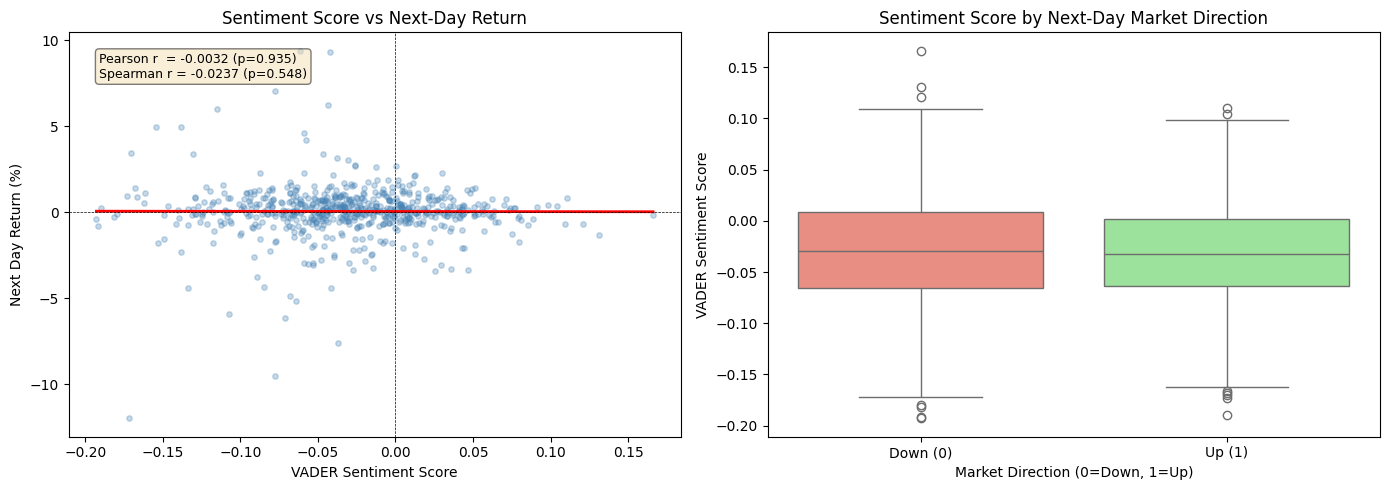

Pearson Correlation  : r = -0.0032, p-value = 0.9351
Spearman Correlation : r = -0.0237, p-value = 0.5481


In [ ]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot — scatterplot with regression line
axes[0].scatter(merged['sentiment_score'], merged['next_day_return'],
                alpha=0.3, color='steelblue', s=15)

# Draw regression line manually
z = np.polyfit(merged['sentiment_score'], merged['next_day_return'], 1)
p = np.poly1d(z)
x_line = np.linspace(merged['sentiment_score'].min(),
                     merged['sentiment_score'].max(), 100)
axes[0].plot(x_line, p(x_line), color='red', linewidth=2)

# Compute correlations
pearson_r,  pearson_p  = stats.pearsonr(merged['sentiment_score'],
                                         merged['next_day_return'])
spearman_r, spearman_p = stats.spearmanr(merged['sentiment_score'],
                                          merged['next_day_return'])

axes[0].text(0.05, 0.95,
             f'Pearson r  = {pearson_r:.4f} (p={pearson_p:.3f})\nSpearman r = {spearman_r:.4f} (p={spearman_p:.3f})',
             transform=axes[0].transAxes,
             verticalalignment='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[0].set_title('Sentiment Score vs Next-Day Return')
axes[0].set_xlabel('VADER Sentiment Score')
axes[0].set_ylabel('Next Day Return (%)')
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].axvline(0, color='black', linewidth=0.5, linestyle='--')

# Right plot — boxplot by market direction
sns.boxplot(data=merged, x='market_direction', y='sentiment_score',
            palette={'0': 'salmon', '1': 'lightgreen'}, ax=axes[1])
axes[1].set_title('Sentiment Score by Next-Day Market Direction')
axes[1].set_xlabel('Market Direction (0=Down, 1=Up)')
axes[1].set_ylabel('VADER Sentiment Score')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Down (0)', 'Up (1)'])

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PDS_dataset/plot11_sentiment_vs_return.png', dpi=150)
plt.show()

print(f"Pearson Correlation  : r = {pearson_r:.4f}, p-value = {pearson_p:.4f}")
print(f"Spearman Correlation : r = {spearman_r:.4f}, p-value = {spearman_p:.4f}")

In [ ]:
# Sentiment-based features
merged['sentiment_ma5']  = merged['sentiment_score'].rolling(window=5).mean()
merged['sentiment_ma10'] = merged['sentiment_score'].rolling(window=10).mean()
merged['sentiment_std5'] = merged['sentiment_score'].rolling(window=5).std().fillna(0)

# Lagged return features — what did the market do recently
merged['return_lag1'] = merged['Daily_Return'].shift(1)
merged['return_lag2'] = merged['Daily_Return'].shift(2)
merged['return_lag3'] = merged['Daily_Return'].shift(3)

# Rolling market features
merged['return_ma10']   = merged['Daily_Return'].rolling(window=10).mean()
merged['volatility_10'] = merged['Daily_Return'].rolling(window=10).std()

# News attention feature
merged['log_headline_count'] = np.log1p(merged['headline_count'])

# Drop rows with NaN created by rolling and lag operations
rows_before = len(merged)
merged = merged.dropna()
rows_after = len(merged)

print(f"Rows before feature engineering dropna : {rows_before}")
print(f"Rows after feature engineering dropna  : {rows_after}")
print(f"Rows dropped                           : {rows_before - rows_after}")
print(f"\nAll columns in merged:")
for col in merged.columns:
    print(f"  {col}")

Rows before feature engineering dropna : 642
Rows after feature engineering dropna  : 444
Rows dropped                           : 198

All columns in merged:
  Open
  High
  Low
  Close
  Volume
  Daily_Return
  MA50
  MA200
  Volatility_30
  Day_of_Week
  sentiment_score
  sentiment_std
  headline_count
  next_day_return
  market_direction
  sentiment_ma5
  sentiment_ma10
  sentiment_std5
  return_lag1
  return_lag2
  return_lag3
  return_ma10
  volatility_10
  log_headline_count


In [ ]:
# ════════════════════════════════════════════════════════════
# TECHNICAL INDICATORS  (added to boost accuracy)
# RSI, MACD, and Bollinger Bands are standard signals used
# by quantitative traders — they capture momentum, trend
# reversals, and volatility in a way raw returns cannot.
# ════════════════════════════════════════════════════════════

# ── RSI (Relative Strength Index, 14-day) ────────────────────────────────────
# RSI measures whether the market is overbought (>70) or oversold (<30).
# Formula: 100 - 100/(1 + avg_gain/avg_loss) over a rolling window.
delta   = merged['Daily_Return'].diff()
gain    = delta.clip(lower=0)                  # keep only positive moves
loss    = (-delta).clip(lower=0)               # keep only negative moves (positive)
avg_gain = gain.ewm(com=13, adjust=False).mean()   # exponentially-weighted avg
avg_loss = loss.ewm(com=13, adjust=False).mean()
rs       = avg_gain / avg_loss.replace(0, 1e-9)    # ratio; avoid division by zero
merged['rsi_14'] = 100 - (100 / (1 + rs))

print("RSI-14 sample (first non-NaN values):")
print(merged['rsi_14'].dropna().head())

# ── MACD (Moving Average Convergence Divergence) ─────────────────────────────
# MACD = EMA(12) - EMA(26).  Signal line = EMA(9) of MACD.
# A positive MACD means short-term momentum > long-term — bullish.
ema12 = merged['Close'].ewm(span=12, adjust=False).mean()
ema26 = merged['Close'].ewm(span=26, adjust=False).mean()
merged['macd']        = ema12 - ema26           # raw MACD line
merged['macd_signal'] = merged['macd'].ewm(span=9, adjust=False).mean()  # signal line
merged['macd_hist']   = merged['macd'] - merged['macd_signal']           # histogram

print("\nMACD columns added: macd, macd_signal, macd_hist")

# ── Bollinger Band Width ──────────────────────────────────────────────────────
# Width = (upper_band - lower_band) / middle_band.
# A widening band signals rising volatility; contracting signals calm markets.
bb_window = 20
bb_mid    = merged['Close'].rolling(bb_window).mean()
bb_std    = merged['Close'].rolling(bb_window).std()
bb_upper  = bb_mid + 2 * bb_std
bb_lower  = bb_mid - 2 * bb_std
merged['bb_width']    = (bb_upper - bb_lower) / bb_mid   # normalised bandwidth
merged['bb_position'] = (merged['Close'] - bb_lower) / (bb_upper - bb_lower + 1e-9)
# bb_position: 0 = at lower band (oversold), 1 = at upper band (overbought)

print("Bollinger Band columns added: bb_width, bb_position")
print(f"\nNull counts for new technical features:")
for col in ['rsi_14','macd','macd_signal','macd_hist','bb_width','bb_position']:
    print(f"  {col}: {merged[col].isnull().sum()} NaNs")


RSI-14 sample (first non-NaN values):
Date
2018-10-11    100.000000
2018-10-12    100.000000
2018-10-15     89.983414
2018-10-16     91.266910
2018-10-17     82.257434
Name: rsi_14, dtype: float64

MACD columns added: macd, macd_signal, macd_hist
Bollinger Band columns added: bb_width, bb_position

Null counts for new technical features:
  rsi_14: 1 NaNs
  macd: 0 NaNs
  macd_signal: 0 NaNs
  macd_hist: 0 NaNs
  bb_width: 19 NaNs
  bb_position: 19 NaNs


In [ ]:
# ARIMA RESIDUALS  (hybrid component)

returns = merged['Daily_Return'].values
n       = len(returns)

# Split index matches the train/test split used for XGBoost (80/20)
split_idx = int(n * 0.80)

# Step 1 — fit auto_arima on training data to find best (p,d,q) order
print("Fitting auto_arima on training data (this may take ~30 seconds)...")
arima_model = auto_arima(
    returns[:split_idx],
    start_p=1, start_q=1,
    max_p=3,   max_q=3,
    d=0,                  # returns are already stationary (no differencing needed)
    seasonal=False,       # daily stock returns have no seasonal pattern
    information_criterion='aic',  # use AIC to select the best order
    stepwise=True,        # faster search
    suppress_warnings=True,
    error_action='ignore'
)
print(f"Best ARIMA order selected: {arima_model.order}")

# Step 2 — generate residuals for the FULL series via walk-forward prediction
# For train window: in-sample fitted values → residuals = actual - fitted
train_fitted   = arima_model.predict_in_sample()
train_residuals = returns[:split_idx] - train_fitted

# For test window: rolling 1-step-ahead out-of-sample prediction (no lookahead)
test_residuals = []
refit_every    = 60          # re-fit ARIMA every 60 days to stay current

for i in range(split_idx, n):
    # Only update the model if we are past the initial training period
    # AND it's a designated refit point.
    # The 'returns[split_idx:i]' slice will contain data from the start of the test set
    # up to the previous observation (returns[i-1]).
    if (i - split_idx) % refit_every == 0 and i > split_idx:
        arima_model.update(returns[split_idx:i])
    # If it's the very first prediction for the test set (i == split_idx),
    # the model is already trained on the initial `returns[:split_idx]` and ready to predict.
    # No update is needed before the first prediction.

    pred = arima_model.predict(n_periods=1)[0]
    test_residuals.append(returns[i] - pred)

# Combine and assign back to merged
arima_residuals = np.concatenate([train_residuals, np.array(test_residuals)])

# Safety: pad with 0 if length mismatch (shouldn't happen, but guard against it)
if len(arima_residuals) < n:
    arima_residuals = np.concatenate([np.zeros(n - len(arima_residuals)), arima_residuals])

merged['arima_residual'] = arima_residuals[:n]

# Safety check — residuals must align exactly with merged rows
assert len(arima_residuals) == len(merged), \
    f"ARIMA residual length {len(arima_residuals)} != merged length {len(merged)}. Check for row drops between steps."
print("ARIMA residual alignment confirmed.")

print(f"\nARIMA residuals computed for {n} trading days.")
print(f"Residual stats:")
print(merged['arima_residual'].describe())
print(f"\nInterpretation: a large positive residual means the market moved UP")
print(f"more than ARIMA expected — sentiment may explain that excess movement.")

Fitting auto_arima on training data (this may take ~30 seconds)...
Best ARIMA order selected: (2, 0, 2)
ARIMA residual alignment confirmed.

ARIMA residuals computed for 444 trading days.
Residual stats:
count    444.000000
mean       0.168772
std        1.779747
min      -11.028050
25%       -0.399736
50%        0.155168
75%        0.799344
max       10.338779
Name: arima_residual, dtype: float64

Interpretation: a large positive residual means the market moved UP
more than ARIMA expected — sentiment may explain that excess movement.


In [ ]:
print("Columns available in merged:")
print(merged.columns.tolist())

# sentiment_std comes from daily_sentiment aggregation — confirm it exists
assert 'sentiment_std' in merged.columns, \
    "'sentiment_std' column missing! Check daily_sentiment aggregation."

Columns available in merged:
['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'MA50', 'MA200', 'Volatility_30', 'Day_of_Week', 'sentiment_score', 'sentiment_std', 'headline_count', 'next_day_return', 'market_direction', 'sentiment_ma5', 'sentiment_ma10', 'sentiment_std5', 'return_lag1', 'return_lag2', 'return_lag3', 'return_ma10', 'volatility_10', 'log_headline_count', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_width', 'bb_position', 'arima_residual']


In [ ]:
# ════════════════════════════════════════════════════════════
# FEATURE MATRIX  (16 features total)
# Original 11 + ARIMA residual + 5 technical indicators
# ════════════════════════════════════════════════════════════

feature_cols = [
    # ── Sentiment features (5) ──────────────────────────────
    'sentiment_score',       # raw daily mean VADER compound score
    'sentiment_ma5',         # 5-day rolling mean (short-term trend)
    'sentiment_ma10',        # 10-day rolling mean (medium-term trend)
    'sentiment_std5',        # 5-day rolling std  (opinion volatility)
    'sentiment_std',         # daily spread of sentiment across headlines

    # ── Lagged return features (3) ──────────────────────────
    'return_lag1',           # yesterday's return (strongest predictor)
    'return_lag2',           # 2-day lag
    'return_lag3',           # 3-day lag

    # ── Rolling market features (3) ─────────────────────────
    'return_ma10',           # 10-day rolling mean return
    'volatility_10',         # 10-day rolling std of returns
    'log_headline_count',    # log(1 + daily headline count)

    # ── ARIMA hybrid residual (1) ───────────────────────────
    'arima_residual',        # daily return unexplained by ARIMA(p,d,q)

    # ── Technical indicators (4) ────────────────────────────
    'rsi_14',                # Relative Strength Index (momentum)
    'macd_hist',             # MACD histogram (trend + momentum signal)
    'bb_width',              # Bollinger Band width (volatility regime)
    'bb_position',           # Price position within Bollinger Bands
]

# Drop any rows that became NaN after the new features
rows_before = len(merged)
merged = merged.dropna(subset=feature_cols + ['market_direction'])
rows_after  = len(merged)
print(f"Rows dropped after adding new features: {rows_before - rows_after}")
print(f"Final usable rows: {rows_after}")

X = merged[feature_cols]
y = merged['market_direction']

print(f"\nFeature matrix X: {X.shape}")
print(f"\nAll {len(feature_cols)} features:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2}. {col}")
print(f"\nTarget distribution:")
print(y.value_counts())


Rows dropped after adding new features: 19
Final usable rows: 425

Feature matrix X: (425, 16)

All 16 features:
   1. sentiment_score
   2. sentiment_ma5
   3. sentiment_ma10
   4. sentiment_std5
   5. sentiment_std
   6. return_lag1
   7. return_lag2
   8. return_lag3
   9. return_ma10
  10. volatility_10
  11. log_headline_count
  12. arima_residual
  13. rsi_14
  14. macd_hist
  15. bb_width
  16. bb_position

Target distribution:
market_direction
1    242
0    183
Name: count, dtype: int64


In [ ]:
# Sort by date to ensure proper time ordering
merged = merged.sort_index()
X = merged[feature_cols]
y = merged['market_direction']

# 80% train, 20% test — split by position NOT randomly
split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Total samples    : {len(X)}")
print(f"Training samples : {len(X_train)} (80%)")
print(f"Testing samples  : {len(X_test)} (20%)")
print(f"\nTraining period  : {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Testing period   : {X_test.index.min().date()} to {X_test.index.max().date()}")
print(f"\nTraining class balance:")
print(y_train.value_counts())
print(f"\nTesting class balance:")
print(y_test.value_counts())

Total samples    : 425
Training samples : 340 (80%)
Testing samples  : 85 (20%)

Training period  : 2018-11-06 to 2020-03-16
Testing period   : 2020-03-17 to 2020-07-16

Training class balance:
market_direction
1    191
0    149
Name: count, dtype: int64

Testing class balance:
market_direction
1    51
0    34
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

base_model = xgb.XGBClassifier(
    subsample         = 0.8,
    colsample_bytree  = 0.7,
    gamma             = 0.1,
    reg_alpha         = 0.05,
    reg_lambda        = 1.0,
    random_state      = 42,
    eval_metric       = 'logloss',
    use_label_encoder = False
)

param_grid = {
    'n_estimators'    : [300, 500, 700],
    'max_depth'       : [3, 4, 5],
    'learning_rate'   : [0.01, 0.03, 0.05],
    'min_child_weight': [2, 3, 5],
}

print("Running GridSearchCV on TRAINING data only (405 fits)...")
grid_search = GridSearchCV(
    estimator  = base_model,
    param_grid = param_grid,
    cv         = tscv,
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print(f"\nBest params : {grid_search.best_params_}")
print(f"Best CV acc : {grid_search.best_score_*100:.2f}%")

Running GridSearchCV on TRAINING data only (405 fits)...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best params : {'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 300}
Best CV acc : 53.57%


In [ ]:
#TimeSeriesSplit fold-by-fold breakdown

best_params = grid_search.best_params_

fold_model = xgb.XGBClassifier(
    **best_params,
    subsample         = 0.8,
    colsample_bytree  = 0.7,
    gamma             = 0.1,
    reg_alpha         = 0.05,
    reg_lambda        = 1.0,
    random_state      = 42,
    eval_metric       = 'logloss',
    use_label_encoder = False
)

fold_scores = []
print("="*60)
print("TIME SERIES SPLIT — Fold-by-fold breakdown")
print("="*60)

for fold_num, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_val   = X_train.iloc[val_idx]
    y_fold_val   = y_train.iloc[val_idx]

    fold_model.fit(X_fold_train, y_fold_train)
    fold_pred = fold_model.predict(X_fold_val)
    fold_acc  = accuracy_score(y_fold_val, fold_pred)
    fold_scores.append(fold_acc)

    train_start = X_fold_train.index.min().strftime('%Y-%m-%d')
    train_end   = X_fold_train.index.max().strftime('%Y-%m-%d')
    val_start   = X_fold_val.index.min().strftime('%Y-%m-%d')
    val_end     = X_fold_val.index.max().strftime('%Y-%m-%d')

    print(f"\nFold {fold_num}:")
    print(f"  Train : {train_start} → {train_end}  ({len(X_fold_train)} samples)")
    print(f"  Val   : {val_start}   → {val_end}    ({len(X_fold_val)} samples)")
    print(f"  Accuracy : {fold_acc*100:.2f}%")

print("\n" + "="*60)
print(f"  Mean CV Accuracy : {np.mean(fold_scores)*100:.2f}%")
print(f"  Std Dev          : {np.std(fold_scores)*100:.2f}%")
print(f"  Min fold         : {np.min(fold_scores)*100:.2f}%")
print(f"  Max fold         : {np.max(fold_scores)*100:.2f}%")
print("="*60)

TIME SERIES SPLIT — Fold-by-fold breakdown

Fold 1:
  Train : 2018-11-06 → 2019-02-04  (60 samples)
  Val   : 2019-02-05   → 2019-04-25    (56 samples)
  Accuracy : 53.57%

Fold 2:
  Train : 2018-11-06 → 2019-04-25  (116 samples)
  Val   : 2019-04-26   → 2019-07-16    (56 samples)
  Accuracy : 48.21%

Fold 3:
  Train : 2018-11-06 → 2019-07-16  (172 samples)
  Val   : 2019-07-17   → 2019-10-03    (56 samples)
  Accuracy : 55.36%

Fold 4:
  Train : 2018-11-06 → 2019-10-03  (228 samples)
  Val   : 2019-10-04   → 2019-12-23    (56 samples)
  Accuracy : 64.29%

Fold 5:
  Train : 2018-11-06 → 2019-12-23  (284 samples)
  Val   : 2019-12-24   → 2020-03-16    (56 samples)
  Accuracy : 46.43%

  Mean CV Accuracy : 53.57%
  Std Dev          : 6.29%
  Min fold         : 46.43%
  Max fold         : 64.29%


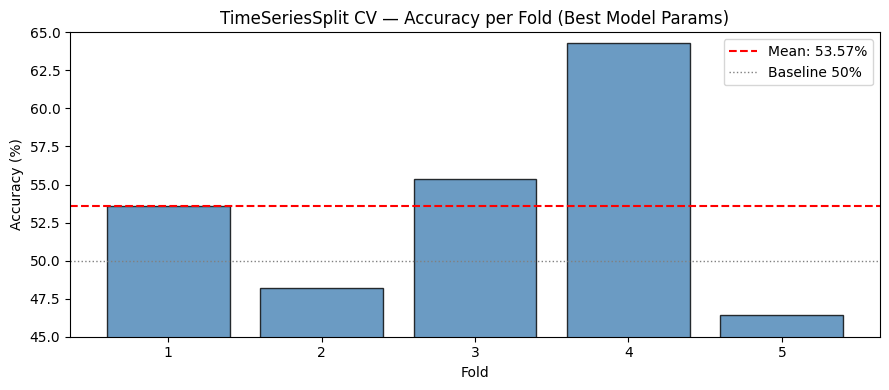

In [ ]:
plt.figure(figsize=(9, 4))
plt.bar(range(1, 6), [s*100 for s in fold_scores],
        color='steelblue', alpha=0.8, edgecolor='black')
plt.axhline(np.mean(fold_scores)*100, color='red', linestyle='--',
            linewidth=1.5, label=f'Mean: {np.mean(fold_scores)*100:.2f}%')
plt.axhline(50, color='gray', linestyle=':', linewidth=1, label='Baseline 50%')
plt.title('TimeSeriesSplit CV — Accuracy per Fold (Best Model Params)')
plt.xlabel('Fold')
plt.ylabel('Accuracy (%)')
plt.ylim(45, 65)
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PDS_dataset/plot_cv_folds.png', dpi=150)
plt.show()

In [ ]:
print("Retraining best model on full training set...")
model = grid_search.best_estimator_
model.fit(X_train, y_train)

y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {accuracy*100:.2f}%")
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Down (0)', 'Up (1)']))

Retraining best model on full training set...
Final Test Accuracy: 58.82%

Full Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.46      0.18      0.26        34
      Up (1)       0.61      0.86      0.72        51

    accuracy                           0.59        85
   macro avg       0.54      0.52      0.49        85
weighted avg       0.55      0.59      0.53        85



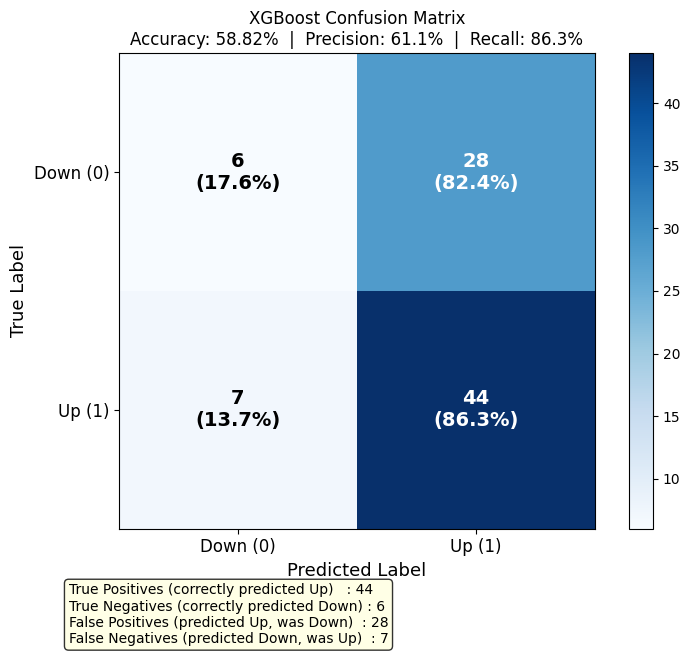

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Calculate percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, ax = plt.subplots(figsize=(8, 6))

# Draw heatmap manually for full control
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

# Add text annotations with both count AND percentage
classes = ['Down (0)', 'Up (1)']
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i,
                f'{cm[i,j]}\n({cm_percent[i,j]:.1f}%)',
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if cm[i,j] > thresh else 'black')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes, fontsize=12)
ax.set_yticklabels(classes, fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.set_title(f'XGBoost Confusion Matrix\nAccuracy: {accuracy*100:.2f}%  |  '
             f'Precision: {tp/(tp+fp)*100:.1f}%  |  '
             f'Recall: {tp/(tp+fn)*100:.1f}%', fontsize=12)

# Add summary stats below
summary = (f'True Positives (correctly predicted Up)   : {tp}\n'
           f'True Negatives (correctly predicted Down) : {tn}\n'
           f'False Positives (predicted Up, was Down)  : {fp}\n'
           f'False Negatives (predicted Down, was Up)  : {fn}')
plt.figtext(0.15, -0.08, summary, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PDS_dataset/plot12_confusion_matrix_v2.png',
            dpi=150, bbox_inches='tight')
plt.show()

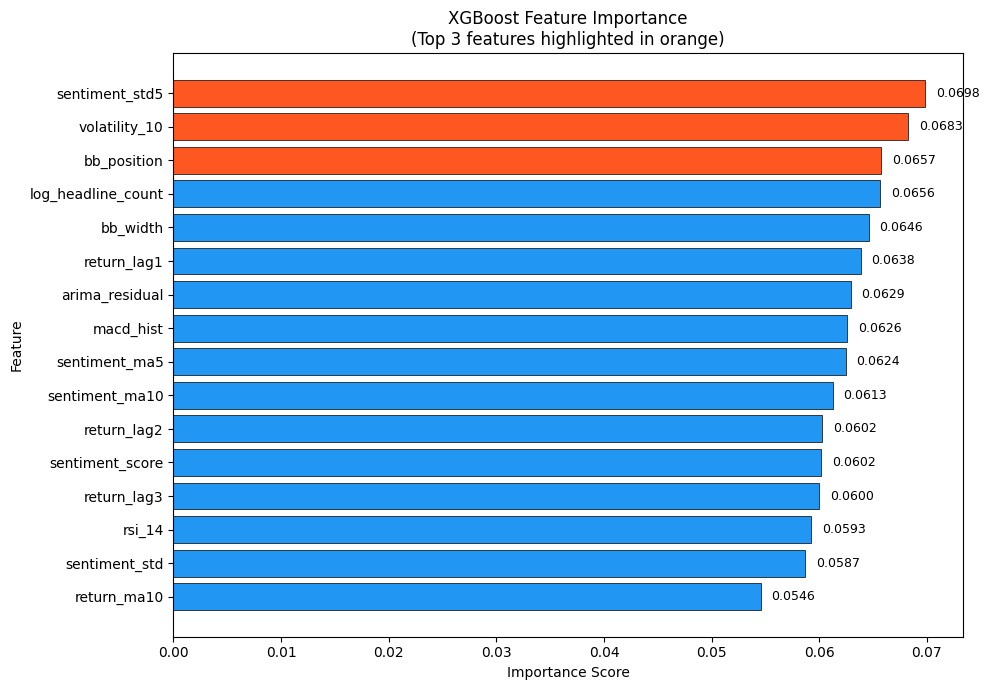


Feature importance ranking:
           feature  importance
    sentiment_std5    0.069823
     volatility_10    0.068272
       bb_position    0.065730
log_headline_count    0.065638
          bb_width    0.064586
       return_lag1    0.063832
    arima_residual    0.062926
         macd_hist    0.062600
     sentiment_ma5    0.062444
    sentiment_ma10    0.061255
       return_lag2    0.060242
   sentiment_score    0.060152
       return_lag3    0.059984
            rsi_14    0.059267
     sentiment_std    0.058690
       return_ma10    0.054559
Plot 13 saved!


In [ ]:
importance_df = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

# Color the top 3 features differently
colors = []
top3_threshold = importance_df['importance'].nlargest(3).min()
for imp in importance_df['importance']:
    if imp >= top3_threshold:
        colors.append('#FF5722')  # orange-red for top 3
    else:
        colors.append('#2196F3')  # blue for rest

plt.figure(figsize=(10, 7))
plt.barh(importance_df['feature'], importance_df['importance'],
         color=colors, edgecolor='black', linewidth=0.5)
plt.title('XGBoost Feature Importance\n(Top 3 features highlighted in orange)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

# Add value labels on bars
for i, (feat, imp) in enumerate(zip(importance_df['feature'],
                                     importance_df['importance'])):
    plt.text(imp + 0.001, i, f'{imp:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PDS_dataset/plot13_feature_importance.png', dpi=150)
plt.show()

print("\nFeature importance ranking:")
print(importance_df.sort_values('importance', ascending=False)
      .to_string(index=False))
print("Plot 13 saved!")

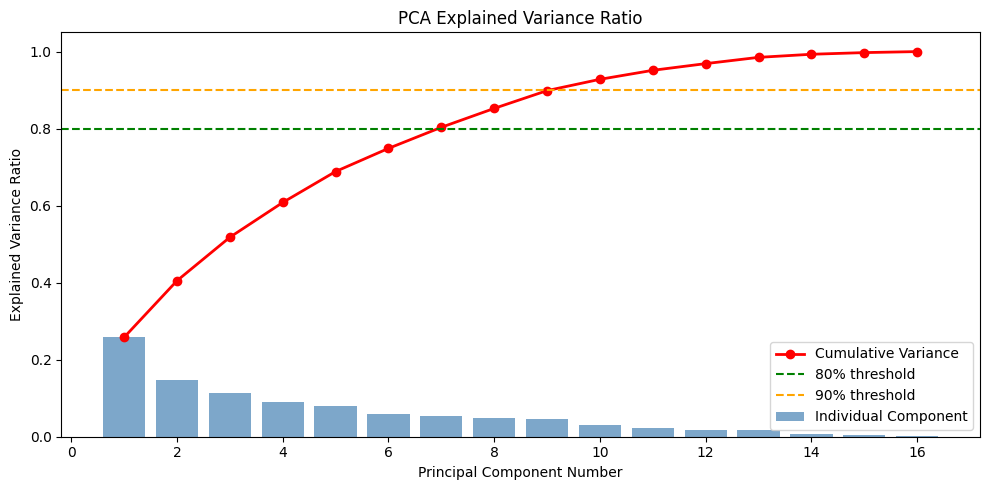

Components needed for 80% variance : 7
Components needed for 90% variance : 10

Variance per component:
  PC1: 25.83%  (cumulative: 25.83%)
  PC2: 14.69%  (cumulative: 40.52%)
  PC3: 11.28%  (cumulative: 51.80%)
  PC4: 9.03%  (cumulative: 60.83%)
  PC5: 8.03%  (cumulative: 68.86%)
  PC6: 6.01%  (cumulative: 74.87%)
  PC7: 5.47%  (cumulative: 80.35%)
  PC8: 4.90%  (cumulative: 85.25%)
  PC9: 4.62%  (cumulative: 89.87%)
  PC10: 2.93%  (cumulative: 92.80%)
  PC11: 2.34%  (cumulative: 95.14%)
  PC12: 1.74%  (cumulative: 96.88%)
  PC13: 1.63%  (cumulative: 98.50%)
  PC14: 0.80%  (cumulative: 99.31%)
  PC15: 0.43%  (cumulative: 99.74%)
  PC16: 0.26%  (cumulative: 100.00%)
Plot 14 saved!


In [ ]:
# Standardize features before PCA
# PCA is sensitive to scale — larger numbers dominate without scaling
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA on all components first to see explained variance
pca_full            = PCA()
pca_full.fit(X_scaled)
explained_variance  = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# How many components needed to explain 80% of variance
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

plt.figure(figsize=(10, 5))

# Bar chart for individual component variance
plt.bar(range(1, len(explained_variance)+1), explained_variance,
        color='steelblue', alpha=0.7, label='Individual Component')

# Line chart for cumulative variance
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance,
         color='red', marker='o', linewidth=2, label='Cumulative Variance')

# Threshold lines
plt.axhline(0.80, color='green', linestyle='--',
            linewidth=1.5, label='80% threshold')
plt.axhline(0.90, color='orange', linestyle='--',
            linewidth=1.5, label='90% threshold')

plt.title('PCA Explained Variance Ratio')
plt.xlabel('Principal Component Number')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PDS_dataset/plot14_pca_variance.png', dpi=150)
plt.show()

print(f"Components needed for 80% variance : {n_components_80}")
print(f"Components needed for 90% variance : {n_components_90}")
print(f"\nVariance per component:")
for i, var in enumerate(explained_variance, 1):
    print(f"  PC{i}: {var*100:.2f}%  (cumulative: {cumulative_variance[i-1]*100:.2f}%)")
print("Plot 14 saved!")

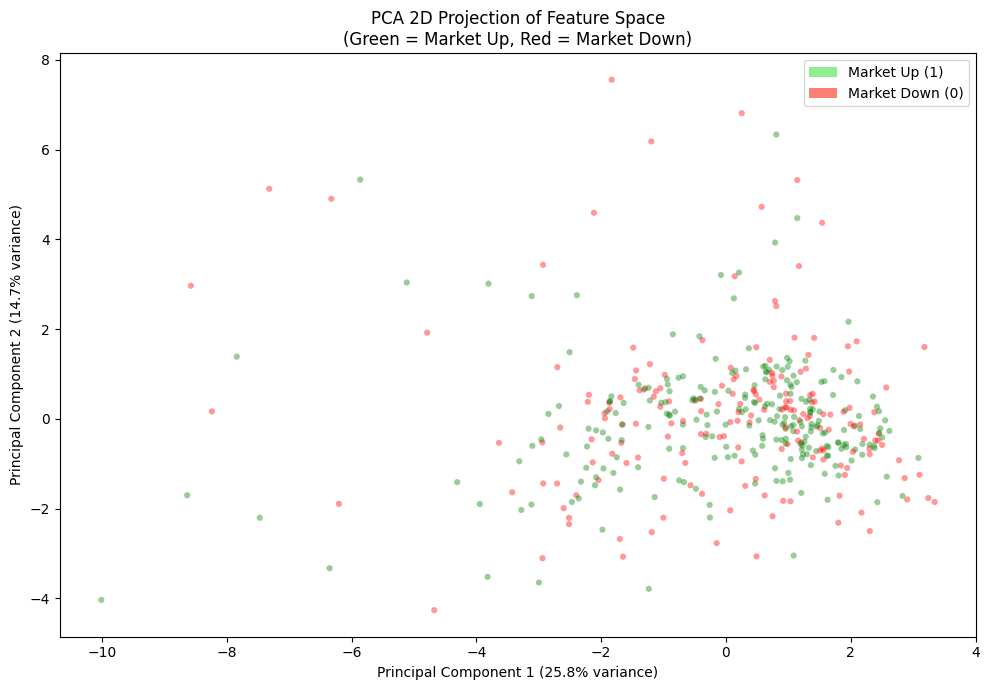

PC1 explains: 25.8% of variance
PC2 explains: 14.7% of variance
Together    : 40.5% of variance
Plot 15 saved!


In [ ]:
# Reduce to 2 components for visualization
pca_2d   = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Create color list based on actual market direction labels
color_map  = {0: 'red', 1: 'green'}
color_list = [color_map[label] for label in y]

plt.figure(figsize=(10, 7))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
            c=color_list, alpha=0.4, s=20, edgecolors='none')

plt.title('PCA 2D Projection of Feature Space\n(Green = Market Up, Red = Market Down)')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]*100:.1f}% variance)')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightgreen', label='Market Up (1)'),
    Patch(facecolor='salmon',     label='Market Down (0)')
]
plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PDS_dataset/plot15_pca_scatter.png', dpi=150)
plt.show()

print(f"PC1 explains: {explained_variance[0]*100:.1f}% of variance")
print(f"PC2 explains: {explained_variance[1]*100:.1f}% of variance")
print(f"Together    : {(explained_variance[0]+explained_variance[1])*100:.1f}% of variance")
print("Plot 15 saved!")